# Step 6 (optional): A toy Antarctic ice-shelf margin

Could warm water at depth and meltwater at the surface create a threshold in the far-field ocean temperature near an Antarctic ice shelf? This is a toy model I made up, not from a paper, and every parameter is an order-of-magnitude guess. I test two mixing laws and scan the uncertain parameters.

I load the libraries and the Antarctic toy model functions from `src/models.py`. `%matplotlib inline` makes the figures show inside the notebook. The two `sys.path` lines let Python find `models.py`, which sits in the `src/` folder.

In [1]:
%matplotlib inline

import os

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")   # models.py lives in the project's src/ folder

from models import (antarctic_tendency, antarctic_melt, antarctic_Tfar_of_T,
                    antarctic_jacobian, classify_eigenvalues)

These are the parameter values. The freshening and cooling per metre of melt come from simple salt and heat budgets, worked out here from basic quantities.

In [2]:
# ---------------- parameters ----------------
# Units: temperature in deg C above freezing, salinity in psu, time in years.
TAU_IN = 1.0          # years for far-field inflow to replace the subsurface water on the shelf
KAPPA0 = 5.0          # 1/yr: rate vertical mixing removes subsurface heat with no freshening (~10-week e-folding)
M_MELT = 10.0         # m of ice per year per (deg C)^2: quadratic melt coefficient (order of magnitude only)
TAU_F = 1.0           # years for surface freshening to be removed (export by currents, sea-ice growth)
F0 = 0.2              # psu: a guess; mixing halves at F = F0 (rational form) or falls by a factor e (exponential)

# Converting melt into freshening and cooling (simple mass and heat budgets)
S_REF = 34.5          # psu: reference salinity of shelf water
AREA_RATIO = 0.1      # ice-shelf base area divided by the area of the shelf sea it drains into
H_SURF = 200.0        # m: thickness of the surface layer that gets freshened
D_SUB = 400.0         # m: thickness of the subsurface warm layer
RHO_ICE = 917.0       # kg/m^3: density of ice
LATENT = 3.34e5       # J/kg: latent heat of melting
RHO_CP = 4.1e6        # J/(m^3 K): volumetric heat capacity of seawater
RHO_SW = 1028.0       # kg/m^3: density of seawater

# Melting 1 m of ice adds RHO_ICE kg of fresh water per m^2, which dilutes a layer
# holding RHO_SW * H_SURF kg of seawater per m^2.
C_FRESH = S_REF * AREA_RATIO * (RHO_ICE / RHO_SW) / H_SURF  # psu of freshening per m of ice melted
B_COOL = RHO_ICE * LATENT * AREA_RATIO / (RHO_CP * D_SUB)  # deg C of cooling per m of melt

T_FAR_MAX = 5.0       # sweep the far-field temperature from 0 to this and back (deg C above freezing)
N_SWEEP = 101         # values in each direction (step 0.05 deg C)
T_SETTLE = 100.0      # years at each far-field temperature; long, because the system leaves slowly just past a fold
DT = 0.01             # Euler time step (years); fastest rate is about kappa0 = 5 per year

T_GRID_MAX = 8.0      # subsurface temperatures used to draw the equilibrium curve
N_T_GRID = 4001

KAPPA0_SCAN = np.linspace(0.5, 30.0, 60)                 # mixing rates tried in the parameter scan (1/yr)
F0_SCAN = np.logspace(np.log10(0.02), np.log10(2.0), 60)  # freshening scales tried in the scan (psu)

FIG_DIR = "../figures"
# --------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

This function collects all model parameters in one dictionary, so I can change the mixing law or a single parameter easily.

In [3]:
def make_params(form, kappa0=KAPPA0, f0=F0, b=B_COOL):
    """All model parameters in one dictionary."""
    return {"tau_in": TAU_IN, "kappa0": kappa0, "m": M_MELT, "tau_F": TAU_F, "F0": f0,
            "c": C_FRESH, "b": b, "form": form}


This function finds the folds. It draws the steady-state curve T_far(T) and looks for places where its slope changes sign. No sign change means no threshold.

In [4]:
def fold_points(par):
    """Far-field temperatures at the folds, or an empty list if there are none.

    Like Cessi's p(y), the steady-state curve T_far(T) has a fold wherever
    its slope changes sign. If it only ever rises, each T_far has exactly
    one steady state and there is no threshold.
    """
    T_grid = np.linspace(0.0, T_GRID_MAX, N_T_GRID)
    T_far = antarctic_Tfar_of_T(T_grid, par)
    slope = np.diff(T_far)
    folds = []
    for i in range(len(slope) - 1):
        if slope[i] * slope[i + 1] < 0:
            folds.append(T_far[i + 1])
    return folds

This function runs forward Euler and returns the final state.

In [5]:
def run_euler(T0, F0_start, T_far, par, dt, t_end):
    """Forward Euler; returns the final T and F."""
    n_steps = int(round(t_end / dt))
    T = T0
    F = F0_start
    for i in range(n_steps):
        dTdt, dFdt = antarctic_tendency(T, F, T_far, par)
        T = T + dt * dTdt
        F = F + dt * dFdt
    return T, F

This function steps the far-field temperature up or down, starting each step from the previous end state, as in step 2. It also records how far from steady each step ends.

In [6]:
def sweep(T_far_values, T0, F0_start, par):
    """Step through far-field temperatures, starting each from the previous end state."""
    T_end = np.zeros(len(T_far_values))
    F_end = np.zeros(len(T_far_values))
    worst_residual = 0.0
    T = T0
    F = F0_start
    for k in range(len(T_far_values)):
        T, F = run_euler(T, F, T_far_values[k], par, DT, T_SETTLE)
        T_end[k] = T
        F_end[k] = F
        # How far from steady the state still is at the end of this step
        dTdt, dFdt = antarctic_tendency(T, F, T_far_values[k], par)
        worst_residual = max(worst_residual, abs(dTdt), abs(dFdt))
    return T_end, F_end, worst_residual

This function splits the steady states into stable and unstable parts using the Jacobian.

In [7]:
def equilibrium_branches(par):
    """Steady states along the T grid, split into stable and unstable parts."""
    T_grid = np.linspace(0.0, T_GRID_MAX, N_T_GRID)
    T_far = antarctic_Tfar_of_T(T_grid, par)
    T_stable = np.full(N_T_GRID, np.nan)
    T_unstable = np.full(N_T_GRID, np.nan)
    for i in range(N_T_GRID):
        F_eq = par["c"] * par["tau_F"] * antarctic_melt(T_grid[i], par)
        eigs = np.linalg.eigvals(antarctic_jacobian(T_grid[i], F_eq, T_far[i], par))
        if classify_eigenvalues(eigs).startswith("stable"):
            T_stable[i] = T_grid[i]
        else:
            T_unstable[i] = T_grid[i]
    return T_far, T_stable, T_unstable

This function finds the smallest mixing rate kappa0 that gives a fold, by bisection. The cooling coefficient b can be changed, for the test without melt cooling below.

In [8]:
def minimum_kappa0_for_fold(form, f0, b=B_COOL):
    """Smallest kappa0 that gives a fold, by bisection (NaN if none up to 200/yr)."""
    low = 0.01
    high = 200.0
    if fold_points(make_params(form, high, f0, b)) == []:
        return np.nan
    for it in range(50):
        mid = 0.5 * (low + high)
        if fold_points(make_params(form, mid, f0, b)) == []:
            low = mid
        else:
            high = mid
    return 0.5 * (low + high)


For both mixing laws I find the folds, run the sweep up and down, draw the equilibrium branches, and find the smallest kappa0 for a fold.

In [9]:
forms = ["rational", "exponential"]
T_far_up = np.linspace(0.0, T_FAR_MAX, N_SWEEP)
T_far_down = np.linspace(T_FAR_MAX, 0.0, N_SWEEP)

# ---- 1. Equilibria, folds and sweeps for both mixing shapes ----
results = {}
for form in forms:
    par = make_params(form)
    T_up, F_up, res_up = sweep(T_far_up, 0.0, 0.0, par)
    T_down, F_down, res_down = sweep(T_far_down, T_up[-1], F_up[-1], par)
    T_far_curve, T_stable, T_unstable = equilibrium_branches(par)
    results[form] = {"par": par, "folds": fold_points(par),
                     "T_up": T_up, "F_up": F_up, "T_down": T_down, "F_down": F_down,
                     "T_far_curve": T_far_curve, "T_stable": T_stable, "T_unstable": T_unstable,
                     "max_gap": np.max(np.abs(T_up - T_down[::-1])),
                     "residual": max(res_up, res_down),
                     "kappa0_min": minimum_kappa0_for_fold(form, F0)}

This is the parameter scan. For each combination of kappa0 and F0 I check whether there is a fold, and whether it falls inside 0-4 deg C.

In [10]:
# ---- 2. Parameter scan: where does a fold exist? ----
# 1 = at least one fold (threshold), 0 = none. Also record whether the
# fold falls inside the plausible far-field range 0-4 deg C.
scan = {}
for form in forms:
    has_fold = np.zeros((len(F0_SCAN), len(KAPPA0_SCAN)))
    for i in range(len(F0_SCAN)):
        for j in range(len(KAPPA0_SCAN)):
            folds = fold_points(make_params(form, KAPPA0_SCAN[j], F0_SCAN[i]))
            if len(folds) > 0:
                has_fold[i, j] = 1
                if max(folds) <= 4.0:
                    has_fold[i, j] = 2
    scan[form] = has_fold

Why do the two laws differ so much? Without the melt cooling term, the steady state is T_far = T + tau_in kappa(F(T)) T, and a fold needs the heat loss kappa T to fall as T rises, faster than 1/tau_in. For the rational law kappa T can fall at most at the rate kappa0/8; for the exponential law at 2 exp(-1.5) kappa0 = 0.446 kappa0. So without melt cooling a fold needs kappa0 tau_in > 8 or > 2.24, whatever F0, c, m and tau_F are. I check this numerically. At the same F0 the exponential law always mixes less, so I also run it with F0 chosen so that both laws halve the mixing at the same freshening.

In [11]:
# ---- 3. Why the two laws differ ----
# By hand, with b = 0 (no melt cooling):
#   rational:    steepest fall of kappa*T is kappa0/8          -> fold if kappa0*tau_in > 8
#   exponential: steepest fall of kappa*T is 2 exp(-1.5) kappa0 -> fold if kappa0*tau_in > exp(1.5)/2
analytic_kappa0 = {"rational": 8.0 / TAU_IN, "exponential": np.exp(1.5) / 2.0 / TAU_IN}
numeric_kappa0_no_cooling = {}
for form in forms:
    numeric_kappa0_no_cooling[form] = minimum_kappa0_for_fold(form, F0, b=0.0)

# Like-for-like: exp(-F/F0') = 1/2 at F = F0 when F0' = F0 / ln 2
F0_MATCHED = F0 / np.log(2.0)
folds_matched = fold_points(make_params("exponential", KAPPA0, F0_MATCHED))


This figure shows the equilibria and sweeps for both mixing laws.

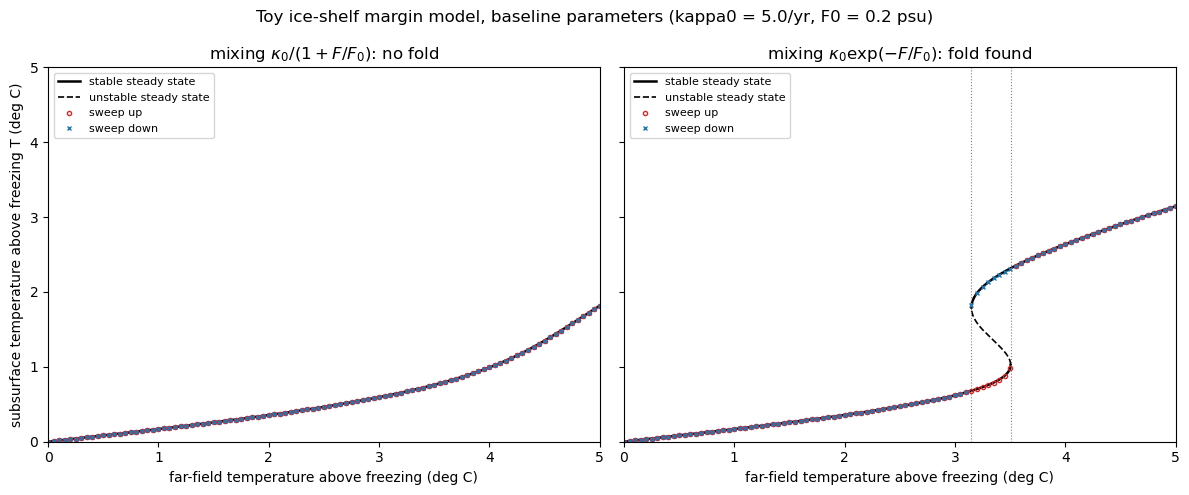

In [12]:
# ---- 4. Figure 1: equilibria and sweeps ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for k in range(2):
    form = forms[k]
    r = results[form]
    ax = axes[k]
    ax.plot(r["T_far_curve"], r["T_stable"], "k-", lw=1.8, label="stable steady state")
    ax.plot(r["T_far_curve"], r["T_unstable"], "k--", lw=1.2, label="unstable steady state")
    ax.plot(T_far_up, r["T_up"], "o", color="tab:red", ms=3, mfc="none", label="sweep up")
    ax.plot(T_far_down, r["T_down"], "x", color="tab:blue", ms=3, label="sweep down")
    for f in r["folds"]:
        ax.axvline(f, color="gray", ls=":", lw=0.8)
    ax.set_xlim(0, T_FAR_MAX)
    ax.set_ylim(0, T_FAR_MAX)
    ax.set_xlabel("far-field temperature above freezing (deg C)")
    if form == "rational":
        ax.set_title(r"mixing $\kappa_0/(1+F/F_0)$: " + ("fold found" if r["folds"] else "no fold"))
    else:
        ax.set_title(r"mixing $\kappa_0 \exp(-F/F_0)$: " + ("fold found" if r["folds"] else "no fold"))
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("subsurface temperature above freezing T (deg C)")
fig.suptitle(f"Toy ice-shelf margin model, baseline parameters (kappa0 = {KAPPA0}/yr, F0 = {F0} psu)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_antarctic_sweeps.png"), dpi=150)
plt.show()

This figure shows the parameter scan as a map, with my baseline parameters marked by a star.

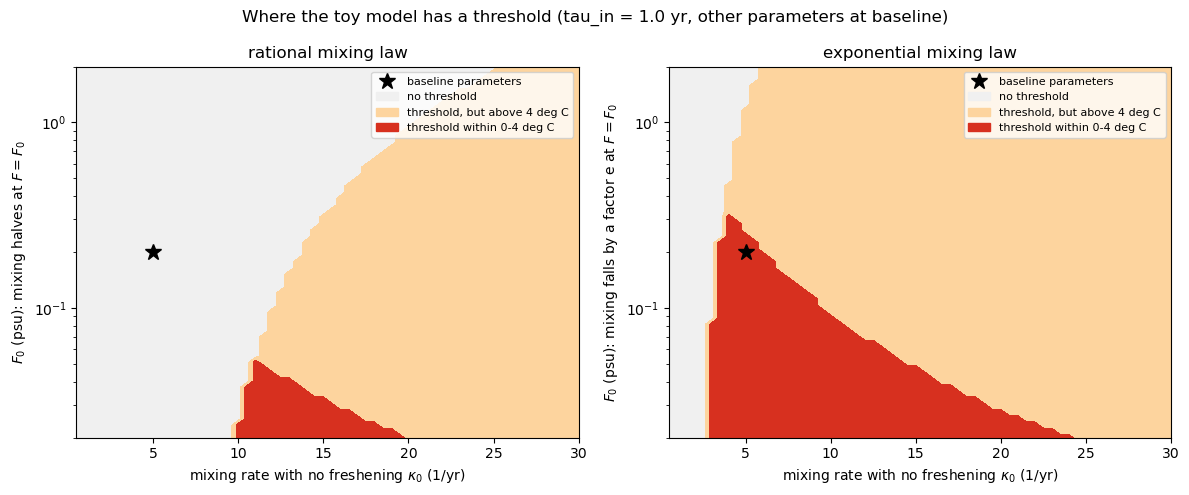

In [13]:
# ---- 5. Figure 2: parameter scan ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = ["#f0f0f0", "#fdd49e", "#d7301f"]   # no fold / fold above 4 deg C / fold within 0-4 deg C
for k in range(2):
    form = forms[k]
    ax = axes[k]
    ax.contourf(KAPPA0_SCAN, F0_SCAN, scan[form], levels=[-0.5, 0.5, 1.5, 2.5], colors=colors)
    ax.plot(KAPPA0, F0, "k*", ms=12, label="baseline parameters")
    # Empty patches, only for the legend
    ax.fill([], [], color=colors[0], label="no threshold")
    ax.fill([], [], color=colors[1], label="threshold, but above 4 deg C")
    ax.fill([], [], color=colors[2], label="threshold within 0-4 deg C")
    ax.set_yscale("log")
    ax.set_xlabel(r"mixing rate with no freshening $\kappa_0$ (1/yr)")
    ax.set_title(f"{form} mixing law")
    if form == "rational":
        ax.set_ylabel(r"$F_0$ (psu): mixing halves at $F = F_0$")
    else:
        ax.set_ylabel(r"$F_0$ (psu): mixing falls by a factor e at $F = F_0$")
        ax.yaxis.set_tick_params(labelleft=True)
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle(f"Where the toy model has a threshold (tau_in = {TAU_IN} yr, other parameters at baseline)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_antarctic_parameter_scan.png"), dpi=150)
plt.show()

Finally I print the derived coefficients, and for each mixing law the folds, the sweep gap, the settling check, the state at T_far = 2, and the smallest kappa0 for a fold.

In [14]:
# ---- 6. Print the key numbers ----
print(f"Derived coefficients: freshening {C_FRESH:.4f} psu per m of melt, cooling {B_COOL:.4f} deg C per m of melt")
print()
for form in forms:
    r = results[form]
    print(f"Mixing law: {form}")
    if r["folds"]:
        fold_text = ", ".join(f"{f:.3f}" for f in r["folds"])
        print(f"  folds at far-field temperature (deg C): {fold_text}")
    else:
        print("  no fold: one steady state for every far-field temperature")
    print(f"  largest gap between sweep up and sweep down: {r['max_gap']:.4f} deg C")
    print(f"  largest |dT/dt| or |dF/dt| at the end of a sweep step: {r['residual']:.2e} per year")
    i2 = np.argmin(np.abs(T_far_up - 2.0))
    melt_2 = antarctic_melt(r["T_up"][i2], r["par"])
    print(f"  on the way up at T_far = {T_far_up[i2]:.2f}: T = {r['T_up'][i2]:.3f} deg C, "
          f"F = {r['F_up'][i2]:.3f} psu, melt = {melt_2:.1f} m/yr")
    print(f"  smallest kappa0 giving a fold (F0 = {F0} psu): {r['kappa0_min']:.2f} per year "
          f"(kappa0 x tau_in = {r['kappa0_min'] * TAU_IN:.2f})")
    print()

print("Without melt cooling (b = 0), smallest kappa0 for a fold, numerical vs by hand:")
for form in forms:
    print(f"  {form:11s}: {numeric_kappa0_no_cooling[form]:.3f} vs {analytic_kappa0[form]:.3f} per year")
print(f"Exponential law with F0 = {F0_MATCHED:.3f} psu (mixing halves at F = {F0} psu, as in the rational law):")
if folds_matched:
    print("  folds at far-field temperature (deg C): " + ", ".join(f"{f:.3f}" for f in folds_matched))
else:
    print("  no fold")

Derived coefficients: freshening 0.0154 psu per m of melt, cooling 0.0187 deg C per m of melt

Mixing law: rational
  no fold: one steady state for every far-field temperature
  largest gap between sweep up and sweep down: 0.0000 deg C
  largest |dT/dt| or |dF/dt| at the end of a sweep step: 5.56e-14 per year
  on the way up at T_far = 2.00: T = 0.356 deg C, F = 0.019 psu, melt = 1.3 m/yr
  smallest kappa0 giving a fold (F0 = 0.2 psu): 13.66 per year (kappa0 x tau_in = 13.66)

Mixing law: exponential
  folds at far-field temperature (deg C): 3.505, 3.149
  largest gap between sweep up and sweep down: 1.3996 deg C
  largest |dT/dt| or |dF/dt| at the end of a sweep step: 1.04e-04 per year
  on the way up at T_far = 2.00: T = 0.357 deg C, F = 0.020 psu, melt = 1.3 m/yr
  smallest kappa0 giving a fold (F0 = 0.2 psu): 3.39 per year (kappa0 x tau_in = 3.39)

Without melt cooling (b = 0), smallest kappa0 for a fold, numerical vs by hand:
  rational   : 8.000 vs 8.000 per year
  exponential: 2